# Canada Restaurant Analytics
## Exploratory Data Analysis

This notebook explores restaurant data collected from the Google Places API and Yelp Fusion API 
across five Canadian cities, enriched with Statistics Canada 2021 census data. 
The analysis connects restaurant performance metrics to neighbourhood demographics 
and compares data quality and coverage between platforms.

---

## Analytical Questions

1. Do neighbourhood demographics influence restaurant ratings?
2. Are expensive restaurants rated higher than budget ones?
3. Which restaurant categories are most popular in each city?
4. Which city has the biggest rating gap between Google and Yelp?
5. Which cities have the most consistent restaurants, and which are the most polarizing?

---


## Setup

In [202]:
import os
import sys
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append(os.path.abspath("../"))

from config.config import CONFIG

db = CONFIG["db"]
params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER=127.0.0.1,1433;"
    f"DATABASE={db['name']};"
    f"UID={db['user']};"
    f"PWD={db['password']};"
    f"TrustServerCertificate=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")


--- 

## 1. Neighbourhood Demographics and Restaurant Ratings

This section uses FSA-level demographic data from the Statistics Canada 2021 census,
including median income and average age, to explore whether neighbourhood characteristics
are associated with restaurant ratings on Google and Yelp.

In [203]:
query = """
SELECT
    dl.city,
    dl.fsa,
    dl.median_income,
    dl.average_age,
    AVG(fr.google_rating) AS avg_google_rating,
    AVG(fr.yelp_rating) AS avg_yelp_rating,
    COUNT(fr.restaurant_key) AS restaurant_count
FROM gold.dim_location dl
LEFT JOIN gold.fact_restaurants fr ON dl.location_key = fr.location_key
GROUP BY dl.city, dl.fsa, dl.median_income, dl.average_age
HAVING COUNT(fr.restaurant_key) >= 3
ORDER BY dl.city, avg_google_rating DESC
"""

df_demo = pd.read_sql(query, engine)
df_display = df_demo.rename(columns={
    "city": "City", 
    "fsa": "FSA", 
    "median_income": "Median Income", 
    "average_age": "Average Age", 
    "avg_google_rating": "Average Google Rating", 
    "avg_yelp_rating": "Average Yelp Rating", 
    "restaurant_count": "Restaurant Count"})

display(df_display.style.hide(axis="index").format({"Median Income": "${:,.0f}", 
                                                    "Average Age": "{:,.0f}", 
                                                    "Average Google Rating": "{:.2f}", 
                                                    "Average Yelp Rating": "{:.2f}"}))

City,FSA,Median Income,Average Age,Average Google Rating,Average Yelp Rating,Restaurant Count
Calgary,T3A,"$110,000",42,4.44,3.97,6
Calgary,T2R,"$72,500",37,4.35,4.17,16
Calgary,T2N,"$94,000",40,4.30,3.80,7
Calgary,T2T,"$93,000",38,4.30,4.00,6
Calgary,T2S,"$88,000",42,4.29,4.30,19
Calgary,T2P,"$67,000",40,4.25,4.17,51
Calgary,T3C,"$75,000",39,4.20,4.40,3
Calgary,T2E,"$77,500",41,4.18,4.21,14
Calgary,T3B,"$96,000",43,4.13,4.08,49
Calgary,T2H,"$68,500",42,4.13,4.20,53


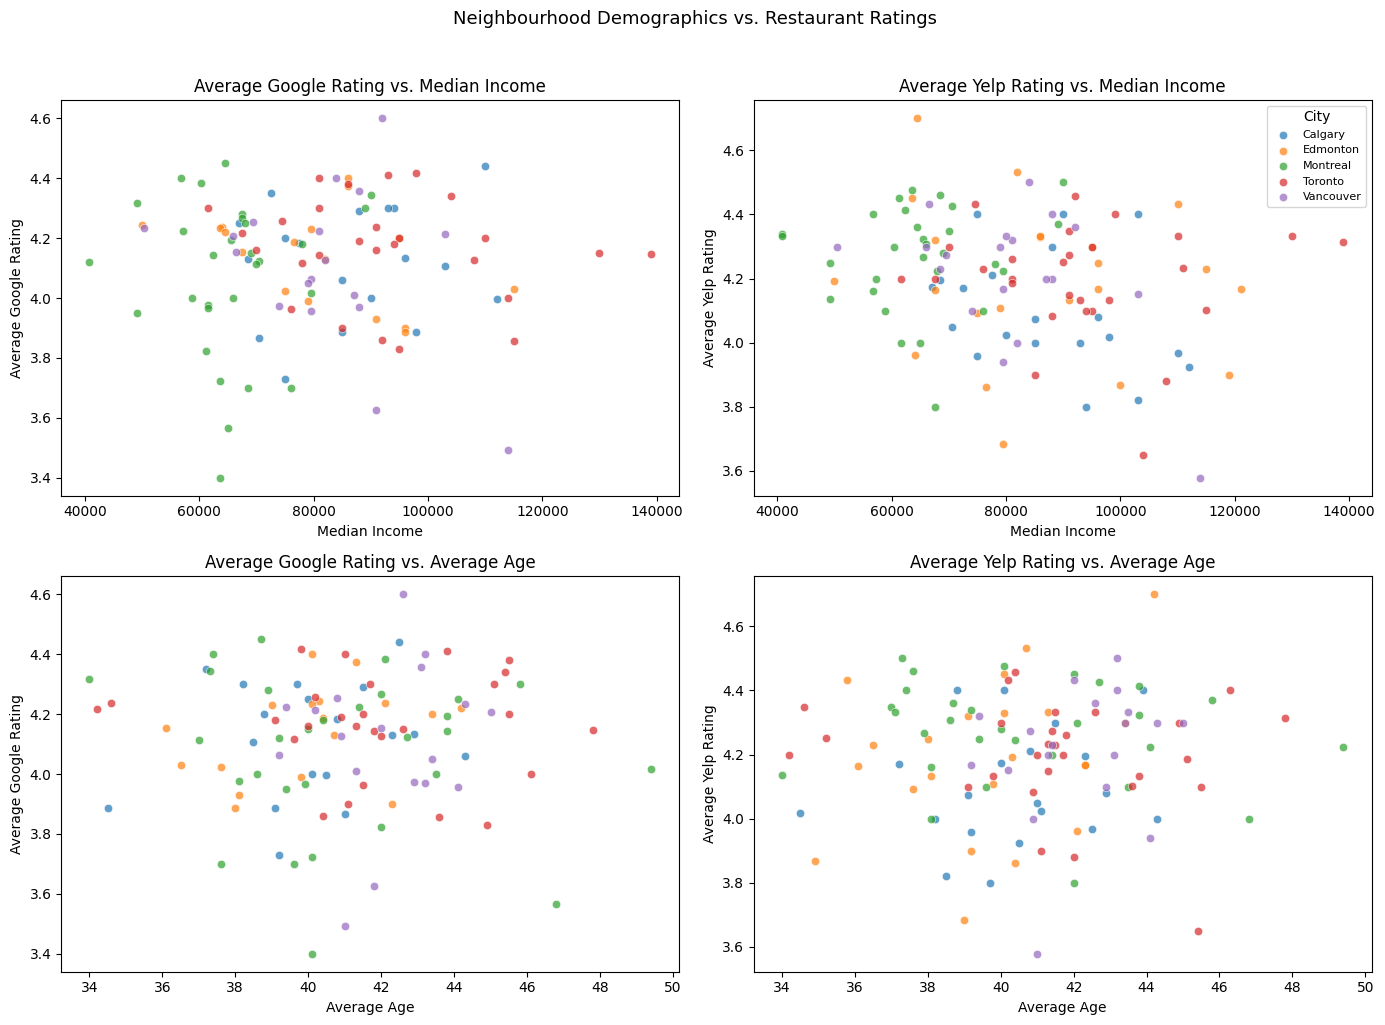

In [204]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [
    ("median_income", "avg_google_rating", "Median Income", "Average Google Rating", axes[0, 0]),
    ("median_income", "avg_yelp_rating", "Median Income", "Average Yelp Rating", axes[0, 1]),
    ("average_age", "avg_google_rating", "Average Age", "Average Google Rating", axes[1, 0]),
    ("average_age", "avg_yelp_rating", "Average Age", "Average Yelp Rating", axes[1, 1]),
]

cities = df_demo["city"].unique()
palette = sns.color_palette("tab10", len(cities))
color_map = dict(zip(cities, palette))

for x_col, y_col, x_label, y_label, ax in pairs:
    plot_df = df_demo.dropna(subset=[x_col, y_col])
    for city, group in plot_df.groupby("city"):
        ax.scatter(
            group[x_col], group[y_col],
            label=city, color=color_map[city],
            alpha=0.7, edgecolors="white", linewidths=0.5
        )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{y_label} vs. {x_label}")

axes[0, 1].legend(title="City", fontsize=8)
plt.suptitle("Neighbourhood Demographics vs. Restaurant Ratings", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Key Observations

- Neither median income nor average age shows a clear correlation with restaurant ratings
  on either platform, suggesting neighbourhood demographics alone do not predict dining quality.
- Google ratings show a slight downward trend at higher income levels, which may reflect
  higher reviewer expectations in wealthier neighbourhoods rather than lower actual quality.
- Yelp ratings are relatively flat across both income and age ranges, with no meaningful
  directional trend in either demographic variable.
- Younger neighbourhoods (average age 34-37) do not consistently rate higher or lower,
  though they tend to cluster in the mid-rating range on both platforms.
- Montreal FSAs stand out as lower income but frequently achieving above-average ratings,
  particularly on Yelp, suggesting that demographic factors explain less of the variation
  than city-level cultural or platform differences.
- The wide vertical spread at any given income or age level confirms that other factors,
  such as cuisine type, price tier, and platform behaviour, are stronger drivers of
  restaurant ratings than neighbourhood demographics.

---

## 2. Price Level Analysis

This section examines restaurant pricing across Canadian cities on both Google and Yelp. 
First, we look at how restaurants are distributed across price levels by city and platform. 
Then we explore whether price level has any relationship with restaurant ratings - do more expensive restaurants actually receive better reviews?

In [205]:
query = """
SELECT 
    dl.city,
    f.google_price_level AS price_level,
    'Google' AS source,
    COUNT(*) AS count
FROM gold.fact_restaurants f
JOIN gold.dim_location dl ON f.location_key = dl.location_key
WHERE f.google_price_level IS NOT NULL
GROUP BY dl.city, f.google_price_level

UNION ALL

SELECT
    dl.city,
    f.yelp_price_level AS price_level,
    'Yelp' AS source,
    COUNT(*) AS count
FROM gold.fact_restaurants f
JOIN gold.dim_location dl ON f.location_key = dl.location_key
WHERE f.yelp_price_level IS NOT NULL
GROUP BY dl.city, f.yelp_price_level

ORDER BY city, source, price_level
"""
df_price = pd.read_sql(query, engine)

price_map = {"$": "Budget", "$$": "Moderate", "$$$": "Pricey", "$$$$": "Luxury"}
df_price["price_level"] = df_price["price_level"].map(price_map)

df_pivot = df_price.pivot_table(
    index=["city", "price_level"],
    columns="source", 
    values="count"
).reset_index()

df_pivot["Google"] = df_pivot["Google"].fillna(0).astype(int)
df_pivot["Yelp"] = df_pivot["Yelp"].fillna(0).astype(int)
df_pivot = df_price.rename(columns={
    "price_level": "Price Level", 
    "city": "City",
    "source": "Source",
    "count": "Count"
})

display(df_pivot.style.hide(axis="index"))


City,Price Level,Source,Count
Calgary,Budget,Google,116
Calgary,Moderate,Google,120
Calgary,Pricey,Google,19
Calgary,Luxury,Google,1
Calgary,Budget,Yelp,26
Calgary,Moderate,Yelp,133
Calgary,Pricey,Yelp,14
Calgary,Luxury,Yelp,2
Edmonton,Budget,Google,107
Edmonton,Moderate,Google,112


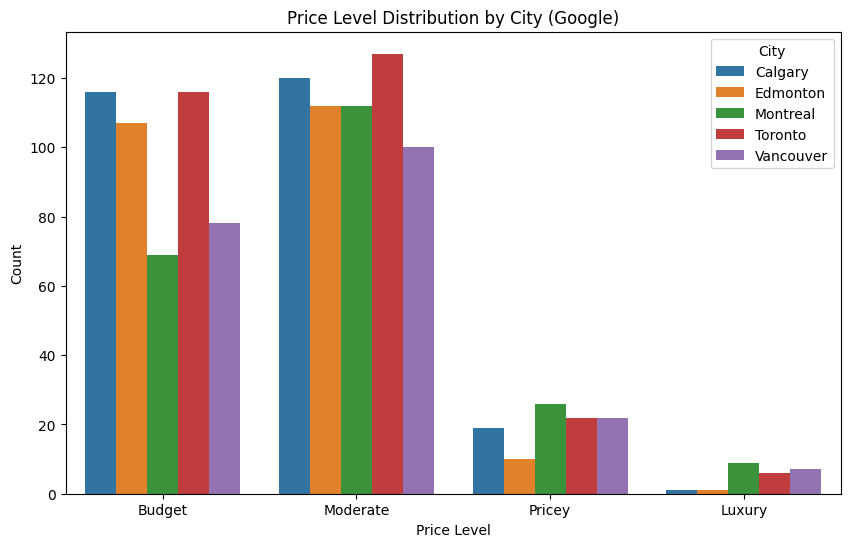

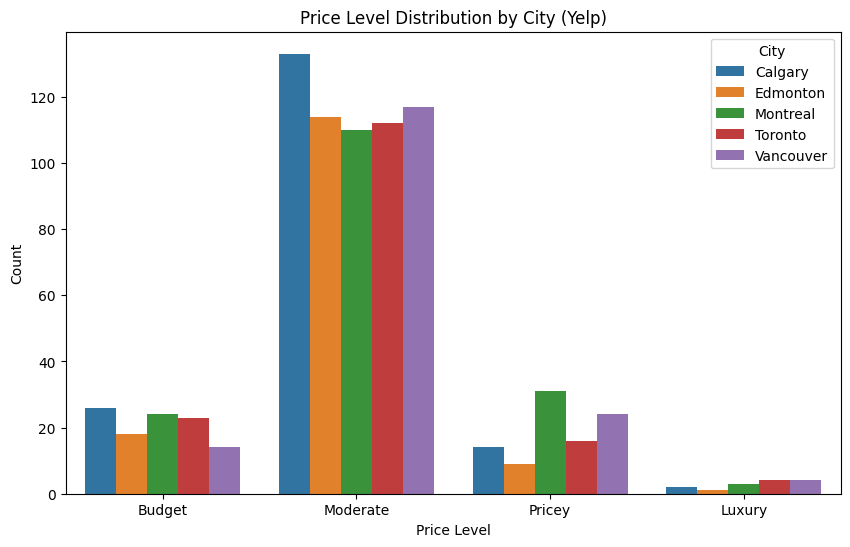

In [206]:
df_chart = df_price.copy()

order = ["Budget", "Moderate", "Pricey", "Luxury"]

df_google = df_chart[df_chart["source"] == "Google"]
df_yelp = df_chart[df_chart["source"] == "Yelp"]

# Google chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_google, x="price_level", y="count", hue="city", order=order)
plt.title("Price Level Distribution by City (Google)")
plt.xlabel("Price Level")
plt.ylabel("Count")
plt.legend(title="City")
plt.show()

# Yelp chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_yelp, x="price_level", y="count", hue="city", order=order)
plt.title("Price Level Distribution by City (Yelp)")
plt.xlabel("Price Level")
plt.ylabel("Count")
plt.legend(title="City")
plt.show()

### Key Observations

- The moderate price tier (`$$`) is the dominant price level across all five cities on both platforms.
- Google captures significantly more budget (`$`) restaurants than Yelp in every city, suggesting lower-cost establishments are more likely to appear in Google"s index.
- Yelp skews toward moderate pricing, which likely reflects a platform bias in which restaurants actively choose to create and maintain listings.
- Calgary has the highest concentration of moderately priced restaurants on Yelp (133), while Montreal has the greatest proportion of upscale (`$$$`) dining options relative to its overall listing count on both platforms.
- Luxury (`$$$$`) restaurants remain rare across the dataset regardless of city or platform.

In [207]:
query = """
WITH cte AS (
    SELECT 
        'Google' AS source,
        AVG(google_rating) AS avg_rating,
        google_price_level AS price_level
    FROM gold.fact_restaurants
    WHERE google_price_level IS NOT NULL
        AND google_rating IS NOT NULL
    GROUP BY google_price_level

    UNION ALL

    SELECT
        'Yelp' AS source,
        AVG(yelp_rating) AS avg_rating,
        yelp_price_level AS price_level
    FROM gold.fact_restaurants
    WHERE yelp_price_level IS NOT NULL
        AND yelp_rating IS NOT NULL
    GROUP BY yelp_price_level
)

SELECT * FROM cte
ORDER BY source, LEN(price_level) ASC
"""
df_price2 = pd.read_sql(query, engine)
df_display = df_price2.rename(columns={"source": "Source", "avg_rating": "Average Rating", "price_level": "Price Level"})
display(df_display.style.hide(axis="index").format({"Average Rating": "{:.2f}"}))


Source,Average Rating,Price Level
Google,3.85,$
Google,4.21,$$
Google,4.42,$$$
Google,4.47,$$$$
Yelp,4.22,$
Yelp,4.04,$$
Yelp,4.18,$$$
Yelp,4.25,$$$$


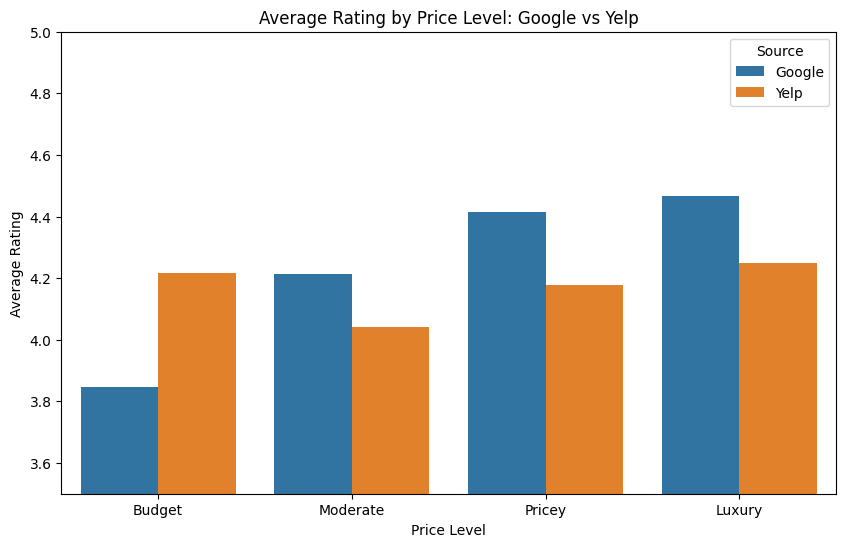

In [208]:
df_price2["price_level"] = df_price2["price_level"].map(price_map)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_price2,
    x="price_level",
    y="avg_rating",
    hue="source",
    order=order
)
plt.title("Average Rating by Price Level: Google vs Yelp")
plt.xlabel("Price Level")
plt.ylabel("Average Rating")
plt.legend(title="Source")
plt.ylim(3.5, 5)
plt.show()

### Key Observations
- On Google there is a clear positive correlation between price and rating. More expensive restaurants consistently receive higher ratings.
- Budget restaurants on Google have the lowest average rating (3.85) while Luxury restaurants have the highest (4.47).
- Yelp shows the opposite pattern. Moderate restaurants rate lower (4.04) than Budget (4.22), with no clear correlation between price and rating.
- The biggest platform gap is at the Budget level. Google rates budget restaurants 0.37 stars lower than Yelp.
- At the Luxury level both platforms converge, with Google (4.47) slightly above Yelp (4.25).
- This suggests Google reviewers may penalize budget restaurants more harshly than Yelp reviewers.

---

## 3. Category Popularity by City

This section explores the distribution of restaurant categories across the five cities,
using Yelp listing data to identify which cuisine types dominate each market
and whether category preferences vary by region.

In [209]:
query = """
WITH category_counts AS (
    SELECT
        dl.city,
        dc.category,
        COUNT(*) AS count,
        ROW_NUMBER() OVER (PARTITION BY dl.city ORDER BY COUNT(*) DESC) AS rn
    FROM gold.fact_restaurants AS fr
    JOIN gold.dim_restaurant AS dr ON fr.restaurant_key = dr.restaurant_key
    JOIN gold.dim_location AS dl ON fr.location_key = dl.location_key
    JOIN gold.dim_category AS dc ON fr.restaurant_key = dc.restaurant_key
    GROUP BY dl.city, dc.category
)
SELECT city, category, count
FROM category_counts
WHERE rn <= 10
ORDER BY city, count DESC
"""

df_cat = pd.read_sql(query, engine)
df_display = df_cat.rename(columns={"city": "City", "category": "Category", "count": "Count"})
display(df_display.style.hide(axis="index"))


City,Category,Count
Calgary,Canadian (New),35
Calgary,Vietnamese,26
Calgary,Cocktail Bars,19
Calgary,Burgers,17
Calgary,Breakfast & Brunch,17
Calgary,Sandwiches,16
Calgary,Steakhouses,14
Calgary,Mediterranean,14
Calgary,Japanese,14
Calgary,Bakeries,13


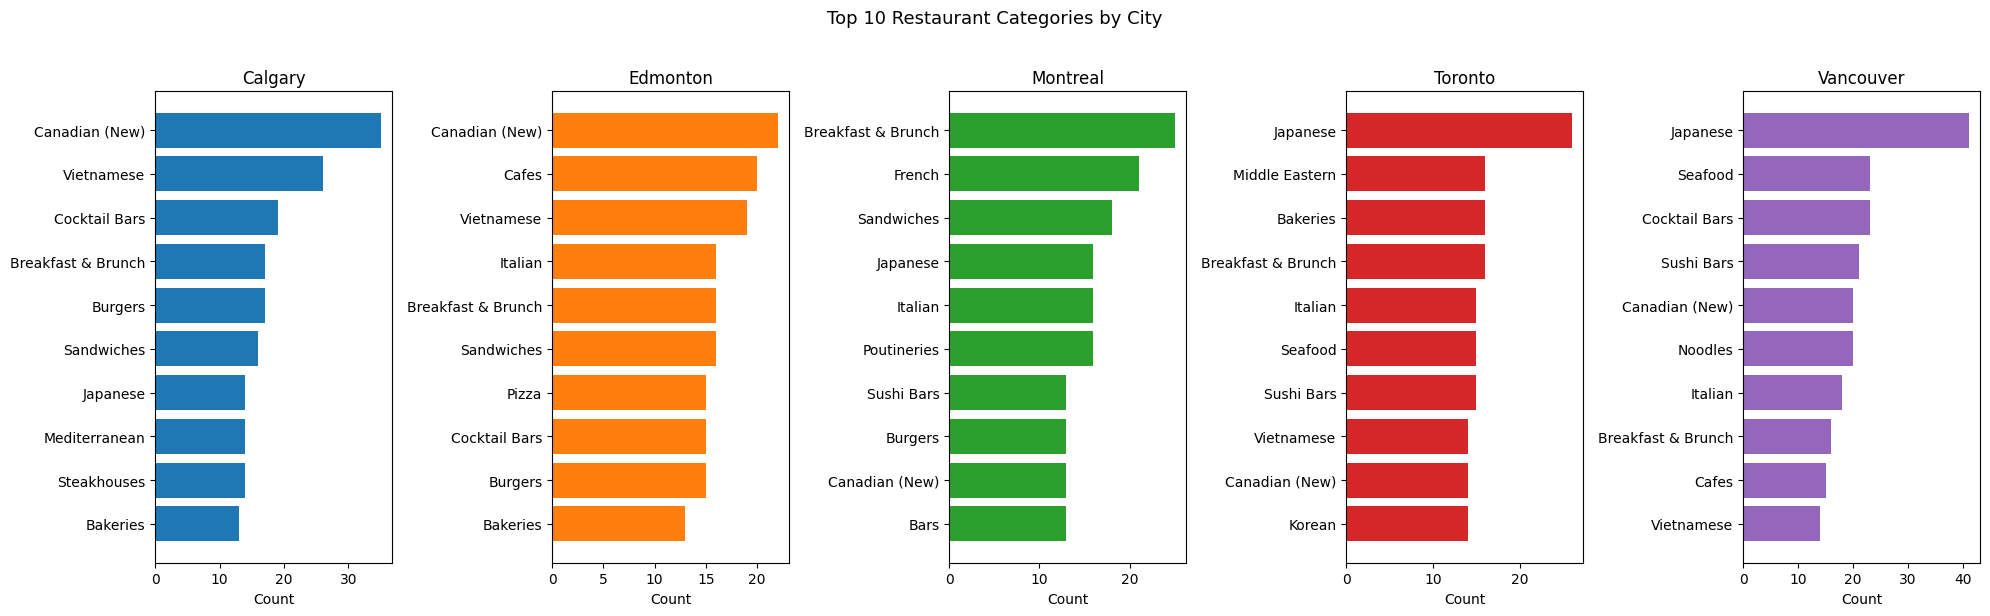

In [210]:
cities = df_cat["city"].unique()
fig, axes = plt.subplots(1, len(cities), figsize=(20, 6), sharey=False)

for ax, city in zip(axes, cities):
    city_df = df_cat[df_cat["city"] == city].sort_values("count", ascending=True)
    ax.barh(city_df["category"], city_df["count"], color=sns.color_palette("tab10")[list(cities).index(city)])
    ax.set_title(city)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.suptitle("Top 10 Restaurant Categories by City", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Key Observations

- Japanese cuisine tops the rankings in both Toronto and Vancouver, while Canadian (New) leads
  in Calgary and Edmonton, suggesting a regional divide in dining preferences across the country.
- Montreal stands out with Breakfast & Brunch as its top category and Poutineries making the
  top 10, the only city where a regionally distinct category appears.
- Vancouver"s top category (Japanese, 41) has a notably higher count than any other city"s
  top category, reflecting both the city"s size and its strong Asian culinary influence.
- Breakfast & Brunch, Vietnamese, Italian, and Canadian (New) appear across multiple cities,
  indicating these are broadly popular categories nationwide rather than city-specific trends.
- Toronto is the only city where Middle Eastern cuisine breaks into the top 10, reflecting
  its more diverse immigrant population relative to the other cities.

---

## 4.  Google vs Yelp Rating Comparison by City

This analysis compares average restaurant ratings across five Canadian cities between Google and Yelp. Both platforms use a 0-5 star rating scale, allowing for direct comparison of how diners rate restaurants in each city.

In [211]:
query = """
SELECT
    d.city,
    AVG(f.google_rating) AS avg_google_rating,
    AVG(f.yelp_rating) AS avg_yelp_rating
FROM gold.fact_restaurants f
JOIN gold.dim_location d
    ON f.location_key = d.location_key
GROUP BY d.city
ORDER BY avg_google_rating DESC
"""

df_rating = pd.read_sql(query, engine)
df_display = df_rating.rename(columns={"avg_google_rating": "Average Google Rating", "avg_yelp_rating": "Average Yelp Rating", "city": "City"})
display(df_display.style.hide(axis="index").format({"Average Google Rating": "{:.2f}", "Average Yelp Rating": "{:.2f}"}))


City,Average Google Rating,Average Yelp Rating
Toronto,4.12,4.21
Edmonton,4.09,4.14
Calgary,4.08,4.07
Vancouver,4.04,4.18
Montreal,4.03,4.30


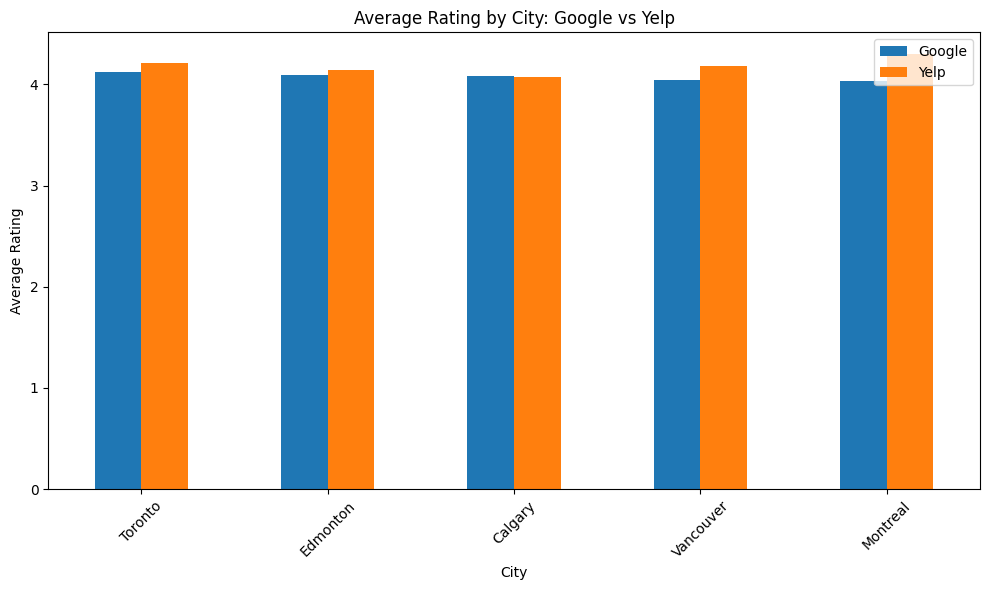

In [212]:
df_rating.plot(
    x="city",
    y=["avg_google_rating", "avg_yelp_rating"],
    kind="bar",
    figsize=(10, 6),
    title="Average Rating by City: Google vs Yelp",
    ylabel="Average Rating",
    xlabel="City",
    label=["Google", "Yelp"],
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Observations
- Yelp ratings are consistently higher than Google ratings across all cities except Calgary, where Google rates slightly higher (4.08 vs 4.07).
- Montreal shows the largest gap between platforms. Yelp rates restaurants 0.27 stars higher on average.
- Vancouver has the lowest Google rating but the second highest Yelp rating, suggesting Yelp users are more generous reviewers in Vancouver.
- Toronto has the highest Google rating of all cities.
- All cities fall in the 4.0-4.3 range, suggesting generally positive dining experiences across Canada.

---

## 5. Rating Consistency and Polarization by City

This section examines rating variance across cities on both platforms to identify
which cities produce the most consistent restaurant experiences and which have the
widest spread between high and low rated restaurants.

In [213]:
query = """
SELECT
    dl.city,
    AVG(fr.google_rating) AS avg_google_rating,
    AVG(fr.yelp_rating) AS avg_yelp_rating,
    STDEV(fr.google_rating) AS stdev_google_rating,
    STDEV(fr.yelp_rating) AS stdev_yelp_rating,
    COUNT(fr.restaurant_key) AS restaurant_count
FROM gold.dim_location dl
LEFT JOIN gold.fact_restaurants fr ON dl.location_key = fr.location_key
GROUP BY dl.city
"""
df_variance = pd.read_sql(query, engine)
df_display = df_variance.rename(columns={
    "avg_google_rating": "Average Google Rating", 
    "avg_yelp_rating": "Average Yelp Rating", 
    "stdev_google_rating": "Standard Deviation Google Rating", 
    "stdev_yelp_rating": "Standard Deviation Yelp Rating", 
    "city": "City", "restaurant_count": "Restaurant Count"})
display(df_display.style.hide(axis="index").format({"Average Google Rating": "{:.2f}", 
                                                    "Average Yelp Rating": "{:.2f}", 
                                                    "Standard Deviation Google Rating": "{:.2f}", 
                                                    "Standard Deviation Yelp Rating": "{:.2f}"}))

City,Average Google Rating,Average Yelp Rating,Standard Deviation Google Rating,Standard Deviation Yelp Rating,Restaurant Count
Montreal,4.03,4.30,0.58,0.32,424
Calgary,4.08,4.07,0.46,0.49,474
Toronto,4.12,4.21,0.41,0.39,509
Edmonton,4.09,4.14,0.49,0.59,480
Vancouver,4.04,4.18,0.56,0.39,443


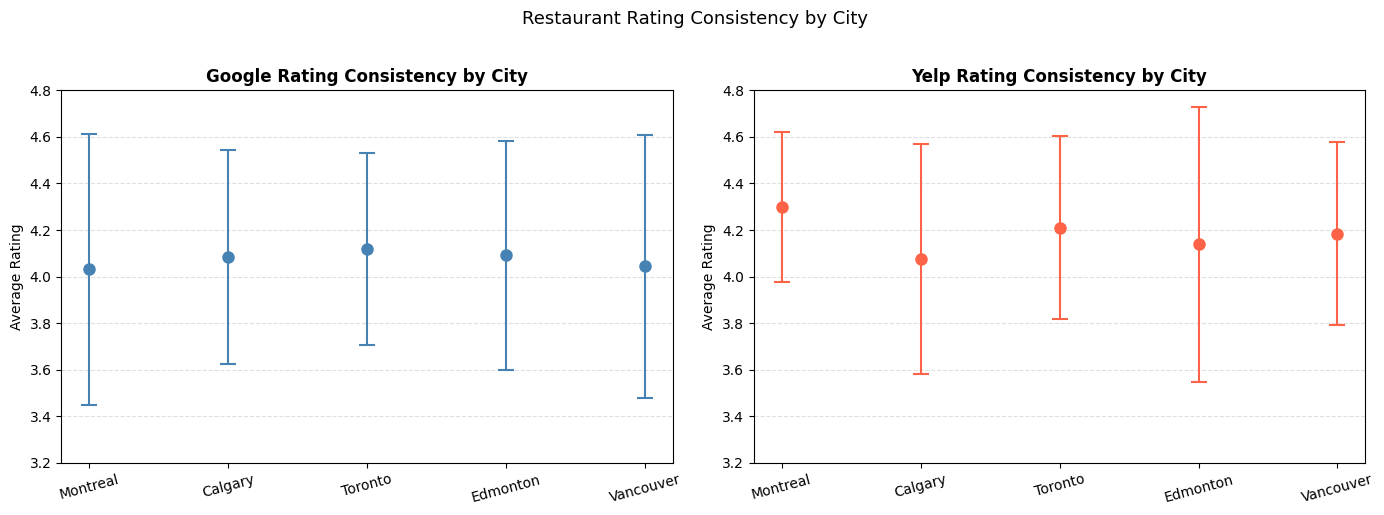

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cities = df_variance["city"].tolist()
x = list(range(len(cities)))

for ax, avg_col, std_col, platform in zip(
    axes,
    ["avg_google_rating", "avg_yelp_rating"],
    ["stdev_google_rating", "stdev_yelp_rating"],
    ["Google", "Yelp"]
):
    ax.errorbar(
        x,
        df_variance[avg_col],
        yerr=df_variance[std_col],
        fmt="o",
        capsize=6,
        capthick=1.5,
        elinewidth=1.5,
        markersize=8,
        color="steelblue" if platform == "Google" else "tomato"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=15)
    ax.set_title(f"{platform} Rating Consistency by City", fontweight="bold")
    ax.set_ylabel("Average Rating")
    ax.set_ylim(3.2, 4.8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Restaurant Rating Consistency by City", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Key Observations

- Toronto is the most consistent city on Google, with the smallest standard deviation (0.41),
  suggesting a more uniform dining experience across neighbourhoods.
- Montreal is the most polarizing city on Google (0.58) but the most consistent on Yelp (0.32),
  pointing to a stark difference in how the two platforms capture restaurant quality there.
- Edmonton shows the opposite pattern, with low Google variance but the highest Yelp variance
  (0.59), indicating Yelp reviewers in Edmonton disagree more than Google reviewers do.
- Average ratings are similar across all five cities on both platforms, hovering around 4.0 to 4.3,
  meaning the spread rather than the average is what distinguishes cities from one another.
- The consistent platform disagreement in variance across cities suggests reviewer behaviour
  and platform composition differ meaningfully between Google and Yelp beyond just rating scale.

---

## Conclusion

This analysis explored restaurant data across five Canadian cities using Google Places and 
Yelp Fusion API data enriched with Statistics Canada 2021 census demographics. Across five 
analytical questions, a few consistent themes emerged.

Neither median income nor average age proved to be a strong predictor of restaurant ratings, 
suggesting that neighbourhood wealth and demographics explain less of the variation in dining 
quality than might be expected. Price tier showed a clearer relationship, but only on Google, 
where ratings rise consistently with price. Yelp showed the opposite pattern, pointing to 
fundamental differences in how each platform's reviewer base evaluates restaurants.

These platform differences surfaced repeatedly throughout the analysis. Montreal was the most 
polarizing city on Google but the most consistent on Yelp, while Edmonton showed the reverse. 
Category preferences also varied meaningfully by city, with Japanese cuisine dominating Toronto 
and Vancouver while Canadian (New) led in Calgary and Edmonton, and Montreal standing out with 
Poutineries as a regionally distinct category.

Taken together, the findings suggest that platform behaviour and city-level cultural factors 
are stronger drivers of restaurant ratings than neighbourhood demographics or price alone. 
Future analysis could incorporate sentiment scoring from review text, additional census 
variables such as population density, or an expanded dataset across more Canadian cities.